## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

**13 - PSO**

14 - Simulation

15 - Map

**Spatial Division 1**

 Region 1: France

 Region 2: others

Spatial Division 2

 Region 1: France _+ Portugal

 Region 2: others


ref: https://pyswarms.readthedocs.io/en/latest/intro.html

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 !pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V6.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V6.npy")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,A_i,occyear1,occyear2,region
0,0,400000000.0,1.796594e+08,0.449148,179.659369,0,0,2
1,1,400000000.0,3.588828e+08,0.897207,358.882792,0,0,2
2,2,400000000.0,2.328088e+08,0.582022,232.808759,1,1,2
3,3,400000000.0,2.426348e+08,0.606587,242.634810,1,1,2
4,4,400000000.0,1.125199e+08,0.281300,112.519858,1,1,2


In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", int(O_j.sum()))
print("occupied year2 =", int(obsyear2.sum()))

n patches = 2567
occupied year1 = 866
occupied year2 = 794


$$
\begin{aligned}
S_i &= \sum_{j\neq i}\exp(-\alpha d_{ij})p_jA_j, \\
C_i &= \frac{S_i^2}{S_i^2+y^2}, \\
E_i &= \min\left[\frac{e}{A_i^x},\,1\right], \\
p_i &= \frac{C_i}{C_i+(1-C_i)\frac{e}{A_i^x}}.
\end{aligned}
$$

$$
\alpha_i =
\begin{cases}
\alpha(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
\alpha(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
y_i =
\begin{cases}
y(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
y(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
e_i =
\begin{cases}
e(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
e(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
x_i =
\begin{cases}
x(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
x(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$


$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$



---



# PSO

In [ ]:
## Define IFM Function:

def run_ifm_rmse(alpha_reg1,  y_reg1, e_reg1, x_reg1,
                 alpha_reg2, y_reg2, e_reg2, x_reg2):

## if i in region 1, use parameters of region 1, else use parameters of region 2

    alpha_i = np.where( region == 1, alpha_reg1, alpha_reg2)

    y_i = np.where(region == 1, y_reg1,  y_reg2)

    e_i = np.where(region == 1, e_reg1, e_reg2)

    x_i = np.where(region == 1, x_reg1, x_reg2)


    K_ij = np.exp(-alpha_i[:, None] * D_ij)

    np.fill_diagonal(K_ij, 0.0)

  # year 1
    S_i_year1 = K_ij @ ( O_j * A_j)

    C_i_year1 = ( S_i_year1 ** 2 / ( S_i_year1 ** 2 + y_i ** 2 ))

    E_i_year1 = np.minimum( e_i / (A_j ** x_i), 1.0)

  # to year 2
    p_i_year2 = ( C_i_year1 / ( C_i_year1 + (1 - C_i_year1) * E_i_year1))


  # define rmse
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return (rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1)


In [ ]:
def objective(params):

    costs = []

    for (
        alpha_reg1,
        y_reg1,
        e_reg1,
        x_reg1,

        alpha_reg2,
        y_reg2,
        e_reg2,
        x_reg2
    ) in params:

        rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
            alpha_reg1,
            y_reg1,
            e_reg1,
            x_reg1,

            alpha_reg2,
            y_reg2,
            e_reg2,
            x_reg2
        )

        n_pred = np.count_nonzero(p_i_year2 > 0.5)

        penalty = 0.0
        # penalty = 0.001 * abs(n_pred - 794)

        costs.append(rmse + penalty)

    return np.array(costs, dtype=float)

## Round 1

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1
# alpha_reg2, y_reg2, e_reg2, x_reg2

In [ ]:
lower_bounds = np.array([0.1, 0.1, 0.001, 0.1,
                         0.1, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
%%time

options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.7       # inertia weight
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=400,    ###
    dimensions=8,
    options=options,
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(
    objective,
    iters=50
)

print("best RMSE:", best_cost)
print("best params:", best_pos)

2026-08-15 11:50:52,960 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.407
2026-08-15 12:39:18,299 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4065654874613959, best pos: [ 1.63242038 79.27281794  3.24759734 10.14752037  1.38121602 74.175615
  5.61848009 12.66024884]


best RMSE: 0.4065654874613959
best params: [ 1.63242038 79.27281794  3.24759734 10.14752037  1.38121602 74.175615
  5.61848009 12.66024884]
CPU times: user 1h 17min 33s, sys: 3min 21s, total: 1h 20min 55s
Wall time: 48min 25s


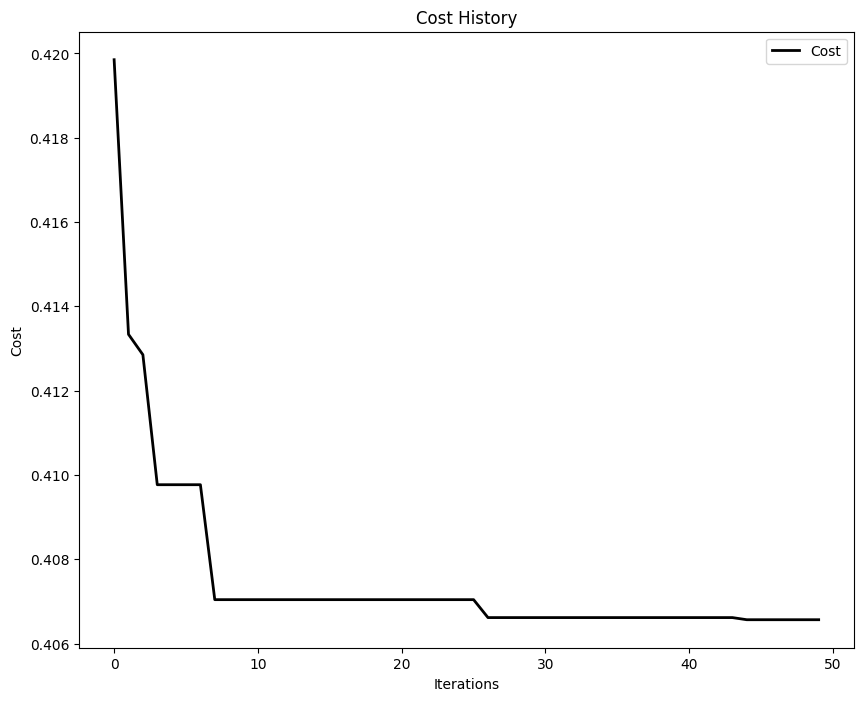

In [ ]:
## round 2.1
plot_cost_history(cost_history=optimizer.cost_history)
plt.show()

#

---

# TEST MULTIPLE SEED

# More social

In [ ]:
## more social round 1
lower_bounds = np.array([0.1, 0.1, 0.001, 0.1,
                         0.1, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)



In [ ]:
## More social

%%time

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_social.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_social_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-15 15:45:15,697 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.404
2026-08-15 16:18:50,559 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4044362600156249, best pos: [ 0.46376104 23.60474256  4.57567958  2.02169758  1.30725026 56.04994214
  6.07937529 11.83476185]
2026-08-15 16:18:50,577 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 137
Best RMSE: 0.4044362600156249
Best params: [ 0.46376104 23.60474256  4.57567958  2.02169758  1.30725026 56.04994214
  6.07937529 11.83476185]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-15 16:54:28,675 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4001493278523216, best pos: [ 1.6535958  61.10915303  5.45244117 10.34689733  0.11004563 95.6738098
  3.33218394  0.50855814]
2026-08-15 16:54:28,691 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 2026
Best RMSE: 0.4001493278523216
Best params: [ 1.6535958  61.10915303  5.45244117 10.34689733  0.11004563 95.6738098
  3.33218394  0.50855814]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.405
2026-08-15 17:26:19,767 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40498294705225113, best pos: [ 0.61051104 35.25054346  5.85324121  3.17202872  1.10056354 28.89711682
  7.80067545  9.72815526]
2026-08-15 17:26:19,801 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...


Seed 890
Best RMSE: 0.4043095765293072
Best params: [ 0.44626052 50.35803543  4.7226393   2.16069693  0.95192016 15.41468039
  7.96605679  8.12588412]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.406
2026-08-15 20:10:38,384 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40566606244522485, best pos: [1.12821858e+00 8.84678135e+01 2.66218322e+00 6.79833862e+00
 8.27739624e-01 5.97767823e+01 1.06682848e-02 6.28866519e+00]
2026-08-15 20:10:38,401 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 1024
Best RMSE: 0.40566606244522485
Best params: [1.12821858e+00 8.84678135e+01 2.66218322e+00 6.79833862e+00
 8.27739624e-01 5.97767823e+01 1.06682848e-02 6.28866519e+00]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.399
2026-08-15 20:45:17,144 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3989858355922371, best pos: [ 1.66390535 71.44351882  9.05487045 10.49794772  0.114324   53.25607083
  8.9375595   0.28079992]



Seed 2048
Best RMSE: 0.3989858355922371
Best params: [ 1.66390535 71.44351882  9.05487045 10.49794772  0.114324   53.25607083
  8.9375595   0.28079992]
CPU times: user 8h 18min 32s, sys: 23min 3s, total: 8h 41min 35s
Wall time: 5h 1s


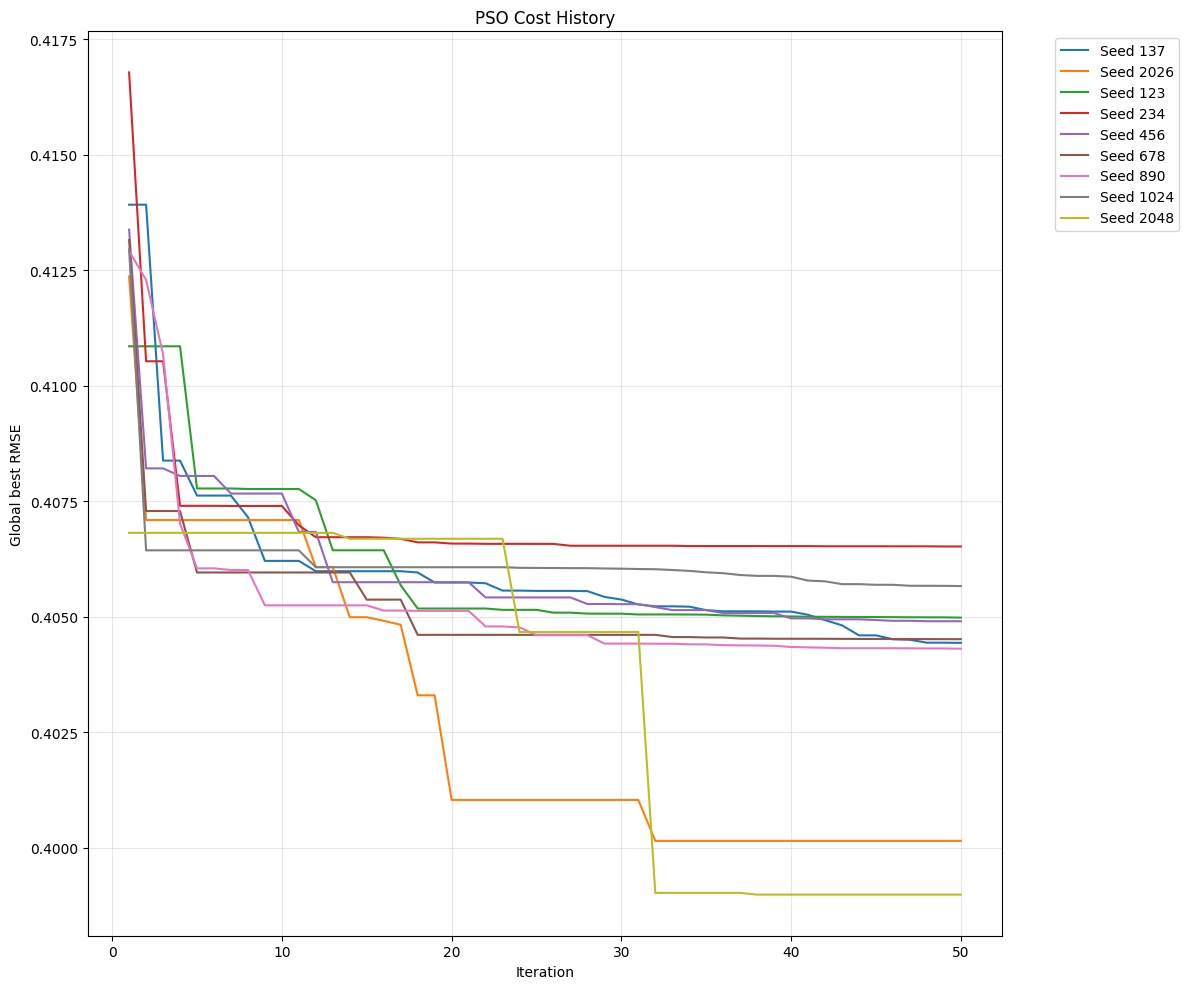

In [ ]:
# more social cost history round 1

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## More social round 2

In [ ]:
## more social round 2
lower_bounds = np.array([0.1, 10, 0.5, 0.5,
                         0.1,  1, 0.1, 0.1])

upper_bounds = np.array([2, 100,  10,  5,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)



In [ ]:
%%time
##   more social round 2

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_social_round2.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_social_round2_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


In [ ]:
# %%time


# seed_pos = np.array([
#     1.663905351, 71.44351882, 9.05487045, 10.49794772,
#     0.1143239983, 53.25607083, 8.937559498, 0.2807999188
# ])

# options = {
#     "c1": 0.7,       # cognitive parameter
#     "c2": 1.5,       # social parameter
#     "w": 0.5
# }


# n_particles = 300
# dimensions = 8
# n_iterations = 50

# result_df = pd.DataFrame(columns=[
#     "seed", "rmse",
#     "alpha_reg1", "y_reg1", "e_reg1", "x_reg1",
#     "alpha_reg2", "y_reg2", "e_reg2", "x_reg2"
# ])

# history_df = pd.DataFrame(
#     columns=["seed", "iteration", "best_rmse"]
# )

# result_df = pd.read_csv(result_path)
# history_df = pd.read_csv(history_path)

# seeds = [890, 1024, 2048]

# for seed in seeds:

#     np.random.seed(seed)

#     init_pos = np.random.uniform(
#         low=lower_bounds,
#         high=upper_bounds,
#         size=(n_particles, dimensions)
#     )

#     init_pos[0] = seed_pos

#     optimizer = ps.single.GlobalBestPSO(
#         n_particles=n_particles,
#         dimensions=dimensions,
#         options=options,
#         bounds=bounds,
#         init_pos=init_pos
#     )

#     best_cost, best_pos = optimizer.optimize(
#         objective,
#         iters=n_iterations
#     )

#     new_result = pd.DataFrame(
#         [[seed, best_cost, *best_pos]],
#         columns=[
#             "seed", "rmse",
#             "alpha_reg1", "y_reg1", "e_reg1", "x_reg1",
#             "alpha_reg2", "y_reg2", "e_reg2", "x_reg2"
#         ]
#     )

#     result_df = result_df[result_df["seed"] != seed]
#     result_df = pd.concat([result_df, new_result], ignore_index=True)
#     result_df.to_csv(result_path, index=False)

#     new_history = pd.DataFrame(
#         [[seed, iteration, cost]
#          for iteration, cost in enumerate(optimizer.cost_history, start=1)],
#         columns=["seed", "iteration", "best_rmse"]
#     )

#     history_df = history_df[history_df["seed"] != seed]
#     history_df = pd.concat([history_df, new_history], ignore_index=True)
#     history_df.to_csv(history_path, index=False)

#     print(f"Seed {seed}")
#     print("Best RMSE:", best_cost)
#     print("Best params:", best_pos)
#     print()

In [ ]:
# more social cost history round 2

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##---------Insert seed-42 result ---------------

In [ ]:
# print(p_i_year2[region == 1].mean())
# print(p_i_year2[region != 1].mean(),"\n")

# print(S_i_year1[region == 1].mean())
# print(S_i_year1[region != 1].mean(),"\n")

# print(C_i_year1[region == 1].mean())
# print(C_i_year1[region != 1].mean(),"\n")

# print(E_i_year1[region == 1].mean())
# print(E_i_year1[region != 1].mean())


# More coginitive

In [ ]:
lower_bounds = np.array([0.1, 0.1, 0.001, 0.1,
                         0.1, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
## More cognitive

%%time

options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 0.7,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-15 23:37:06,189 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.406
2026-08-16 00:38:37,971 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4060183975006843, best pos: [ 1.18950054 21.12211643  4.89048001  6.83160407  0.89182984 72.70709648
  4.2169023   7.96424001]
2026-08-16 00:38:38,025 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 42
Best RMSE: 0.4060183975006843
Best params: [ 1.18950054 21.12211643  4.89048001  6.83160407  0.89182984 72.70709648
  4.2169023   7.96424001]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.406
2026-08-16 01:39:07,398 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40592909328728705, best pos: [ 1.00040744 15.11114019  2.27684121  5.32901582  1.18731783 49.60217935
  6.89060985 10.70576121]
2026-08-16 01:39:07,429 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 137
Best RMSE: 0.40592909328728705
Best params: [ 1.00040744 15.11114019  2.27684121  5.32901582  1.18731783 49.60217935
  6.89060985 10.70576121]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.405
2026-08-16 02:36:27,158 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4050739929234364, best pos: [ 0.60108    60.97953463  4.28356942  3.23853605  1.42104788 63.38099582
  5.31173073 12.948471  ]
2026-08-16 02:36:27,191 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 2026
Best RMSE: 0.4050739929234364
Best params: [ 0.60108    60.97953463  4.28356942  3.23853605  1.42104788 63.38099582
  5.31173073 12.948471  ]


pyswarms.single.global_best:  28%|██▊       |14/50, best_cost=0.405

In [ ]:
## More cognitive

%%time

options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 0.7,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-16 09:03:14,163 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.405
2026-08-16 09:53:09,295 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40475529235086893, best pos: [ 0.53334259 28.80879546  3.31569268  2.49435893  1.46175799 31.21031733
  6.17704173 13.14704168]
2026-08-16 09:53:10,403 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 123
Best RMSE: 0.40475529235086893
Best params: [ 0.53334259 28.80879546  3.31569268  2.49435893  1.46175799 31.21031733
  6.17704173 13.14704168]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.406
2026-08-16 10:47:41,252 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40639949932608727, best pos: [ 1.63977276 45.55616106  2.67770184  9.99040944  1.18536315 37.34600573
  7.14396261 10.59289934]
2026-08-16 10:47:41,280 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 234
Best RMSE: 0.40639949932608727
Best params: [ 1.63977276 45.55616106  2.67770184  9.99040944  1.18536315 37.34600573
  7.14396261 10.59289934]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.405
2026-08-16 11:36:48,041 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40460192055998473, best pos: [ 0.50374576 73.9518466   4.51515302  2.66550202  1.06277246 32.68524057
  2.79616858  9.24027188]
2026-08-16 11:36:48,069 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...


Seed 890
Best RMSE: 0.3972136016784149
Best params: [ 0.75028839 35.94241532  5.51518005  4.10309302  0.11309228 38.50649296
  8.87111065  0.27212096]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.406
2026-08-16 14:09:21,772 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4062975843470362, best pos: [ 1.39979962  9.51654685  6.29068534  8.00628236  1.5934376  61.92383367
  8.28945015 14.61094823]
2026-08-16 14:09:21,797 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 1024
Best RMSE: 0.4062975843470362
Best params: [ 1.39979962  9.51654685  6.29068534  8.00628236  1.5934376  61.92383367
  8.28945015 14.61094823]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.407
2026-08-16 15:02:59,087 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40652877348552346, best pos: [ 1.68273794 72.91723121  8.7488017  10.62965699  1.28047005 53.42757626
  6.47418134 11.60313816]



Seed 2048
Best RMSE: 0.40652877348552346
Best params: [ 1.68273794 72.91723121  8.7488017  10.62965699  1.28047005 53.42757626
  6.47418134 11.60313816]
CPU times: user 8h 6min 10s, sys: 36min 15s, total: 8h 42min 25s
Wall time: 5h 59min 44s


In [ ]:
rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*best_pos)

print(p_i_year2.mean())
print(S_i_year1.mean())
print(C_i_year1.mean())
print(E_i_year1.mean(),"\n")

print(np.count_nonzero(p_i_year2[region == 1] > 0.5),"\n")
print(np.count_nonzero(p_i_year2[region != 1]> 0.5),"\n")


print(p_i_year2[region == 1].mean())
print(p_i_year2[region != 1].mean(),"\n")

print(S_i_year1[region == 1].mean())
print(S_i_year1[region != 1].mean(),"\n")

print(C_i_year1[region == 1].mean())
print(C_i_year1[region != 1].mean(),"\n")

print(E_i_year1[region == 1].mean())
print(E_i_year1[region != 1].mean())


0.2759180472162697
1.0441871868826346e-07
1.0443118178252322e-15
0.001558239400960356 

447 

255 

0.30086436900244135
0.24184390077654017 

4.054282040815651e-09
2.41506363952335e-07 

1.2363072670716386e-18
2.469047215656748e-15 

0.002699055331087815
4.991641409491658e-10


In [ ]:
result_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive_combined.csv")

history_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V6_more_cognitive_cost_history_combined.csv")

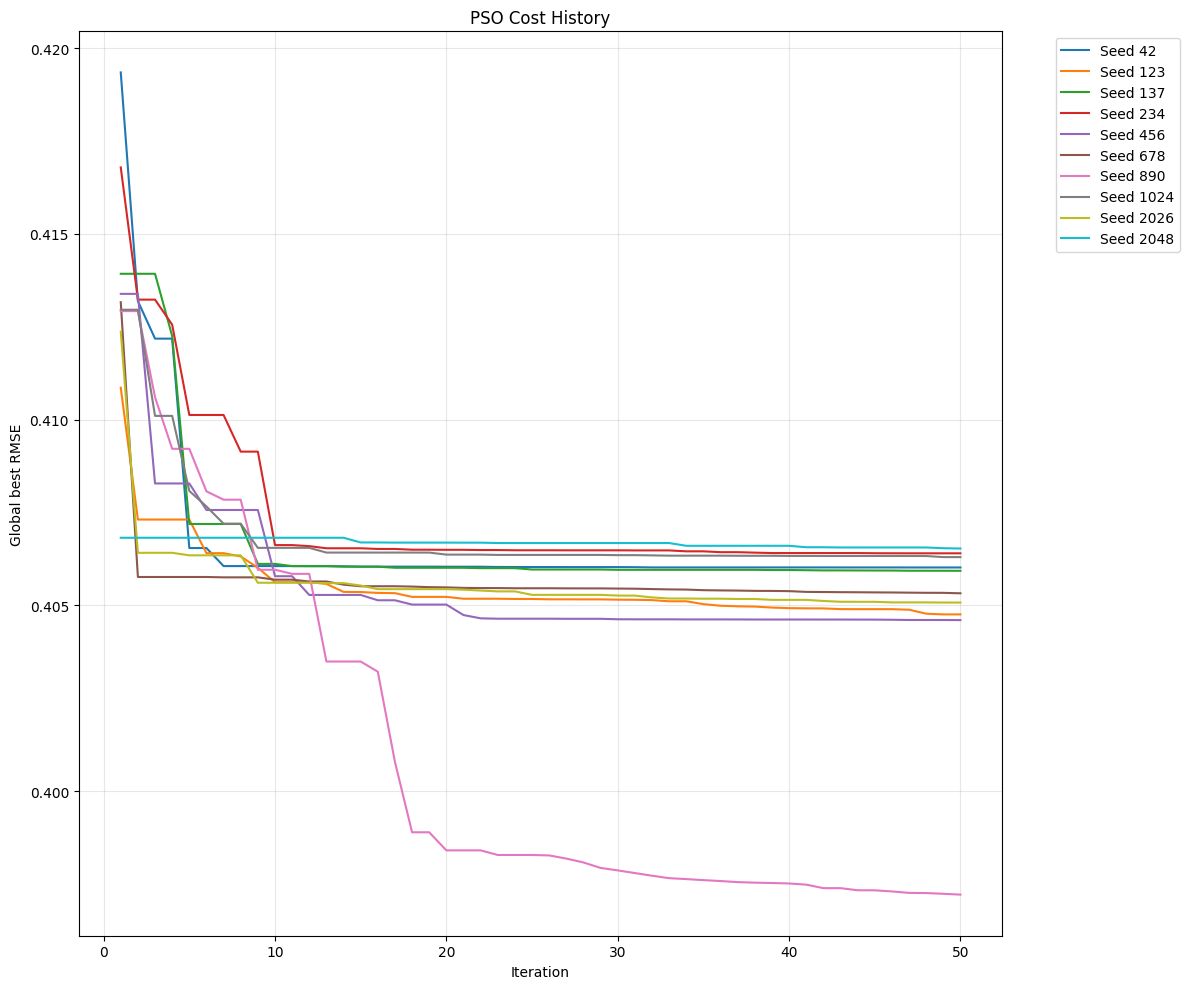

In [ ]:
seeds_in_file = sorted(history_df["seed"].unique())

plt.figure(figsize=(12, 10))

for seed in seeds_in_file:
    df_seed = (
        history_df[history_df["seed"] == seed]
        .sort_values("iteration")
    )

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## More cognitive - Round 2

In [ ]:
# Hornet V6 more cognitive Round 2

%%time

# previous best fittings
seed_pos = np.array([
    0.75028839,  35.94241532,  5.51518005,  4.10309302,
    0.11309228,  38.50649296,  8.87111065,  0.27212096
])


options = {
    "c1": 1.5,       # cognitive parameter
    "c2": 0.7,       # social parameter
    "w": 0.5
}


lower_bounds = np.array([0.1, 1, 0.1, 1,
                         0.05, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 80,  10, 15])

bounds = (lower_bounds, upper_bounds)



n_particles = 300
dimensions = 8
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V6_more_cognitive_round2.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V6_more_cognitive_round2_cost_history.csv")


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    np.random.seed(seed)

    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )

    init_pos[0] = seed_pos


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            "x_reg2"
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )


    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1 ):

        history_results.append([seed, iteration, cost])


    history_df = pd.DataFrame(history_results, columns=["seed", "iteration", "best_rmse"])

    history_df.to_csv(history_path, index=False)


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()


2026-08-16 18:26:56,629 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-16 19:14:24,648 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3970515866031179, best pos: [ 0.70820072 35.68079769  5.62426725  3.82143059  0.11033785 39.10357871
  8.7814244   0.33860297]
2026-08-16 19:14:24,720 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 42
Best RMSE: 0.3970515866031179
Best params: [ 0.70820072 35.68079769  5.62426725  3.82143059  0.11033785 39.10357871
  8.7814244   0.33860297]
Initial position shape: (300, 8)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-16 20:02:02,940 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39703565412101927, best pos: [ 0.74268163 35.41102775  5.48194306  4.04329969  0.10901628 42.59127139
  8.86938967  0.24434907]
2026-08-16 20:02:02,966 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 137
Best RMSE: 0.39703565412101927
Best params: [ 0.74268163 35.41102775  5.48194306  4.04329969  0.10901628 42.59127139
  8.86938967  0.24434907]
Initial position shape: (300, 8)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-16 20:49:20,840 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3970626309624512, best pos: [ 0.74638616 35.80864459  5.48133265  4.07173836  0.10975813 42.29634609
  8.74904832  0.27555497]
2026-08-16 20:49:20,882 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 2026
Best RMSE: 0.3970626309624512
Best params: [ 0.74638616 35.80864459  5.48133265  4.07173836  0.10975813 42.29634609
  8.74904832  0.27555497]
Initial position shape: (300, 8)



pyswarms.single.global_best:  22%|██▏       |11/50, best_cost=0.397

In [ ]:
%%time


# previous best fittings
seed_pos = np.array([
    0.75028839,  35.94241532,  5.51518005,  4.10309302,
    0.11309228,  38.50649296,  8.87111065,  0.27212096
])


options = {
    "c1": 1.5,       # cognitive parameter
    "c2": 0.7,       # social parameter
    "w": 0.5
}


lower_bounds = np.array([0.1, 1, 0.1, 1,
                         0.05, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 80,  10, 15])

bounds = (lower_bounds, upper_bounds)



n_particles = 300
dimensions = 8
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V6_more_cognitive_round2.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V6_more_cognitive_round2_cost_history.csv")



result_df = pd.read_csv(result_path)
history_df = pd.read_csv(history_path)

seeds = [2026, 123, 234, 456, 678, 890, 1024, 2048]

for seed in seeds:

    np.random.seed(seed)

    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )

    init_pos[0] = seed_pos

    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )

    new_result = pd.DataFrame(
        [[seed, best_cost, *best_pos]],
        columns=[
            "seed", "rmse",
            "alpha_reg1", "y_reg1", "e_reg1", "x_reg1",
            "alpha_reg2", "y_reg2", "e_reg2", "x_reg2"
        ]
    )

    result_df = result_df[result_df["seed"] != seed]
    result_df = pd.concat([result_df, new_result], ignore_index=True)
    result_df.to_csv(result_path, index=False)

    new_history = pd.DataFrame(
        [[seed, iteration, cost]
         for iteration, cost in enumerate(optimizer.cost_history, start=1)],
        columns=["seed", "iteration", "best_rmse"]
    )

    history_df = history_df[history_df["seed"] != seed]
    history_df = pd.concat([history_df, new_history], ignore_index=True)
    history_df.to_csv(history_path, index=False)

    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print()

2026-08-16 21:49:25,045 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-16 22:36:23,637 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3970626309624512, best pos: [ 0.74638616 35.80864459  5.48133265  4.07173836  0.10975813 42.29634609
  8.74904832  0.27555497]
2026-08-16 22:36:23,667 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 2026
Best RMSE: 0.3970626309624512
Best params: [ 0.74638616 35.80864459  5.48133265  4.07173836  0.10975813 42.29634609
  8.74904832  0.27555497]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-16 23:23:25,810 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3970742608973857, best pos: [ 0.70691642 51.24831064  5.48739164  3.92845923  0.11142463 38.72557988
  8.90576158  0.21013058]
2026-08-16 23:23:25,855 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 123
Best RMSE: 0.3970742608973857
Best params: [ 0.70691642 51.24831064  5.48739164  3.92845923  0.11142463 38.72557988
  8.90576158  0.21013058]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-17 00:11:04,998 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39691022313328955, best pos: [ 0.76140676 35.905525    5.41027182  4.17311224  0.10449769 48.55641667
  8.8501662   0.18449651]
2026-08-17 00:11:05,023 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...

Seed 890
Best RMSE: 0.3969044431057406
Best params: [ 0.74888367 36.38203104  5.50725467  4.09459525  0.10473274 47.33939817
  8.84954124  0.25316149]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-17 03:20:32,338 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39703466819701105, best pos: [ 0.67170089 36.51952012  5.50497202  3.5822734   0.10490469 40.40006192
  8.91379737  0.27940607]
2026-08-17 03:20:32,362 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


Seed 1024
Best RMSE: 0.39703466819701105
Best params: [ 0.67170089 36.51952012  5.50497202  3.5822734   0.10490469 40.40006192
  8.91379737  0.27940607]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.397
2026-08-17 04:07:16,547 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3971607447479715, best pos: [ 0.7506009  35.88179872  5.51217732  4.10278177  0.11084145 39.71240639
  8.82731536  0.24843482]


Seed 2048
Best RMSE: 0.3971607447479715
Best params: [ 0.7506009  35.88179872  5.51217732  4.10278177  0.11084145 39.71240639
  8.82731536  0.24843482]

CPU times: user 8h 41min 36s, sys: 41min 25s, total: 9h 23min 1s
Wall time: 6h 17min 51s


In [ ]:
rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*best_pos)

print(p_i_year2.mean())
print(S_i_year1.mean())
print(C_i_year1.mean())
print(E_i_year1.mean(),"\n")

print(np.count_nonzero(p_i_year2[region == 1] > 0.5),"\n")
print(np.count_nonzero(p_i_year2[region != 1]> 0.5),"\n")


print(p_i_year2[region == 1].mean())
print(p_i_year2[region != 1].mean(),"\n")

print(S_i_year1[region == 1].mean())
print(S_i_year1[region != 1].mean(),"\n")

print(C_i_year1[region == 1].mean())
print(C_i_year1[region != 1].mean(),"\n")

print(E_i_year1[region == 1].mean())
print(E_i_year1[region != 1].mean())


In [ ]:
# more social cost history
plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()